In [1]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import glob

In [2]:
path = Path("/swgo/Array_Simulato_Analisi_ML/roots_mPMT_gammas_SWGO_array/4FF_R600m_h290r180_black_uniform0600m_100300TeV_030deg/")

PE_True_list = []
E_True_list = []

for file in path.glob("*.root"):
    
    with uproot.open(file) as DAT:
        
        if "XCDF" in DAT:
            tree = DAT["XCDF"]
        else:
            print(f"Skipping {path}: 'XCDF' not found")
            continue
        
    
        df = tree.arrays(library = "pd")
    
        for j in range(1, len(df["HAWCSim.Evt.Num"]) + 1):
            gamma = df[df["HAWCSim.Evt.Num"] == j]
        
            if gamma.empty:
                continue
        
            Energy_True = np.asarray(gamma["HAWCSim.Evt.Energy"].iloc[0])
            PE_True = np.asarray(gamma["HAWCSim.Evt.nPE"].iloc[0])
        
            PE_True_list.append(PE_True)
            E_True_list.append(Energy_True / 1000)

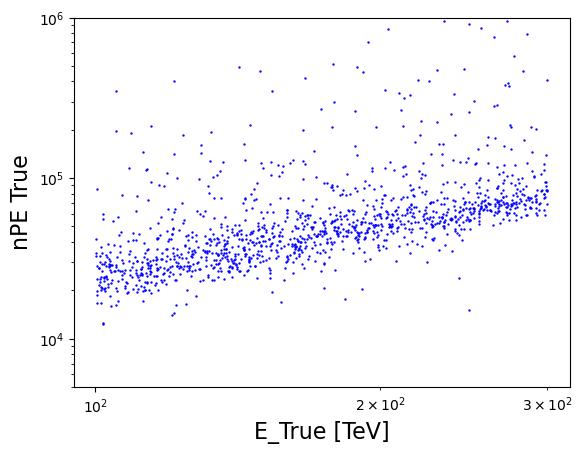

In [3]:
plt.scatter(E_True_list, PE_True_list, marker = ".", s = 2, color = "blue")
plt.xlabel("E_True [TeV]", fontsize = 16)
plt.ylabel("nPE True", fontsize = 16)
plt.yscale("log")
plt.xscale("log")
plt.ylim(0.5e4,1e6)
plt.show()

In [4]:
"""path = Path("/swgo/Array_Simulato_Analisi_ML/roots_mPMT_protons_SWGO_array/4FF_R600m_h175r180_black_uniform0600m_100300TeV_030deg/")

PE_True_list_proton = []
E_True_list_proton = []

for file in path.glob("*.root"):
    try:
        with uproot.open(file) as DAT:
            if "XCDF" in DAT:
                tree = DAT["XCDF"]
            else:
                print(f"Skipping {file}: 'XCDF' not found")
                continue

            df = tree.arrays(library="pd")

    except OSError as e:
        print(f"Skipping {file}: {e}")
        continue

    for j in df["HAWCSim.Evt.Num"].unique():
        proton = df[df["HAWCSim.Evt.Num"] == j]

        if proton.empty:
            continue

        Energy_True = np.asarray(proton["HAWCSim.Evt.Energy"].iloc[0])
        PE_True = np.asarray(proton["HAWCSim.Evt.nPE"].iloc[0])

        PE_True_list_proton.append(PE_True)
        E_True_list_proton.append(Energy_True / 1000)"""

'path = Path("/swgo/Array_Simulato_Analisi_ML/roots_mPMT_protons_SWGO_array/4FF_R600m_h175r180_black_uniform0600m_100300TeV_030deg/")\n\nPE_True_list_proton = []\nE_True_list_proton = []\n\nfor file in path.glob("*.root"):\n    try:\n        with uproot.open(file) as DAT:\n            if "XCDF" in DAT:\n                tree = DAT["XCDF"]\n            else:\n                print(f"Skipping {file}: \'XCDF\' not found")\n                continue\n\n            df = tree.arrays(library="pd")\n\n    except OSError as e:\n        print(f"Skipping {file}: {e}")\n        continue\n\n    for j in df["HAWCSim.Evt.Num"].unique():\n        proton = df[df["HAWCSim.Evt.Num"] == j]\n\n        if proton.empty:\n            continue\n\n        Energy_True = np.asarray(proton["HAWCSim.Evt.Energy"].iloc[0])\n        PE_True = np.asarray(proton["HAWCSim.Evt.nPE"].iloc[0])\n\n        PE_True_list_proton.append(PE_True)\n        E_True_list_proton.append(Energy_True / 1000)'

In [5]:
"""plt.scatter(E_True_list_proton, PE_True_list_proton, marker = ".", s = 2, color = "red", label = "protons", alpha = 1)
plt.scatter(E_True_list, PE_True_list, marker = ".", s = 2, color = "blue", label = "gammas")
plt.xlabel("E_True [TeV]", fontsize = 16)
plt.ylabel("nPE True", fontsize = 16)
plt.yscale("log")
plt.xscale("log")
plt.ylim(1e3, 1e7)
plt.legend(loc = "lower right")
plt.show()"""

'plt.scatter(E_True_list_proton, PE_True_list_proton, marker = ".", s = 2, color = "red", label = "protons", alpha = 1)\nplt.scatter(E_True_list, PE_True_list, marker = ".", s = 2, color = "blue", label = "gammas")\nplt.xlabel("E_True [TeV]", fontsize = 16)\nplt.ylabel("nPE True", fontsize = 16)\nplt.yscale("log")\nplt.xscale("log")\nplt.ylim(1e3, 1e7)\nplt.legend(loc = "lower right")\nplt.show()'

In [6]:
import iminuit 
from iminuit.cost import LeastSquares
from iminuit import Minuit

def linear_regression(x, a, b):
    return a*x + b

yerr = [np.sqrt(i) for i in PE_True_list]

least_squares = LeastSquares(E_True_list, PE_True_list, yerr, linear_regression)
m = Minuit(least_squares, a = 400, b = -6e3)

m.strategy = 2  
m.migrad()

#m.migrad()
#m.hesse() 

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.468e+07 (χ²/ndof = 26512.2)│              Nfcn = 34               │
│ EDM = 1.2e-10 (Goal: 0.0002)     │            time = 1.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │  310.79   │   0.11    │            │            │         │         │       │
│ 1 │ b    │ -5.730e3  │  0.019e3  │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────┐
│   │      a      b │
├───┼───────────────┤
│ a │ 0.0126 -2.037 │
│ b │ -2.037    362 │
└───┴───────────────┘

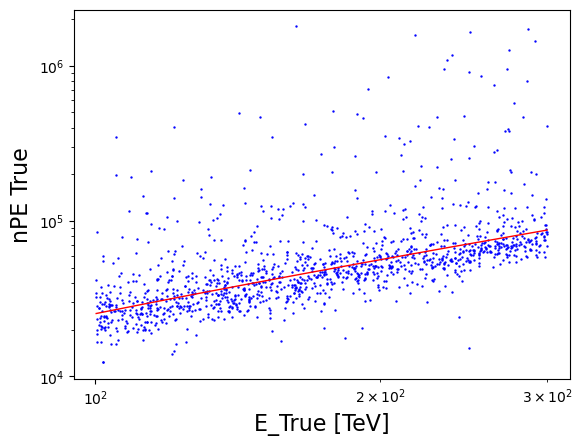

In [7]:
plt.scatter(E_True_list, PE_True_list, marker = ".", s = 2, color = "blue", label = "gammas")
E_100_300_TeV = np.linspace(np.min(E_True_list), np.max(E_True_list), 1000)
plt.plot(np.asarray(E_100_300_TeV), linear_regression(np.asarray(E_100_300_TeV), *m.values), label="linear fit", color = "red", linewidth = 1)

#plt.legend(title="\n".join(fit_info), frameon = False, loc = "lower right")
plt.xlabel("E_True [TeV]", fontsize = 16)
plt.ylabel("nPE True", fontsize = 16)
plt.yscale("log")
plt.xscale("log")
#plt.ylim(1e3, 1e7)
#plt.savefig("pictures/other/npevsEtrue.png", dpi = 300)
plt.show()

In [8]:
"""plt.scatter(E_True_list_proton, PE_True_list_proton, marker = ".", s = 2, color = "red", label = "proton", alpha = 0.1)
plt.scatter(E_True_list, PE_True_list, marker = ".", s = 2, color = "blue", label = "gammas")
E_100_300_TeV = np.linspace(np.min(E_True_list), np.max(E_True_list), 1000)
plt.plot(np.asarray(E_100_300_TeV), linear_regression(np.asarray(E_100_300_TeV), *m.values), label="linear fit", color = "lime", linewidth = 3)

#plt.legend(title="\n".join(fit_info), frameon = False, loc = "lower right")
plt.xlabel("E_True [TeV]", fontsize = 16)
plt.ylabel("nPE True", fontsize = 16)
plt.yscale("log")
plt.xscale("log")
plt.legend(loc = "lower right")
#plt.savefig("pictures/other/npevsEtrue_gamma&protons.png", dpi = 300)

#plt.ylim(1e3, 1e7)
plt.show()"""

'plt.scatter(E_True_list_proton, PE_True_list_proton, marker = ".", s = 2, color = "red", label = "proton", alpha = 0.1)\nplt.scatter(E_True_list, PE_True_list, marker = ".", s = 2, color = "blue", label = "gammas")\nE_100_300_TeV = np.linspace(np.min(E_True_list), np.max(E_True_list), 1000)\nplt.plot(np.asarray(E_100_300_TeV), linear_regression(np.asarray(E_100_300_TeV), *m.values), label="linear fit", color = "lime", linewidth = 3)\n\n#plt.legend(title="\n".join(fit_info), frameon = False, loc = "lower right")\nplt.xlabel("E_True [TeV]", fontsize = 16)\nplt.ylabel("nPE True", fontsize = 16)\nplt.yscale("log")\nplt.xscale("log")\nplt.legend(loc = "lower right")\n#plt.savefig("pictures/other/npevsEtrue_gamma&protons.png", dpi = 300)\n\n#plt.ylim(1e3, 1e7)\nplt.show()'

In [9]:
def inverse_linear(y, a, b):
    return (y - b) / a
    
E_reco_gammas = inverse_linear(np.asarray(PE_True_list), *m.values)
"""E_diff_gammas = [(reco - true)/true for reco, true in zip(E_reco_gammas, E_True_list)]

E_reco_protons = inverse_linear(np.asarray(PE_True_list_proton), *m.values)
E_diff_protons = [(reco - true)/true for reco, true in zip(E_reco_protons, E_True_list_proton)]

res_gamma = np.std(E_reco_gammas)
res_protons = np.std(E_reco_protons)

plt.hist(E_diff_gammas, histtype = "step", color = "blue", label = "gammas", density = True, bins = 300)
plt.hist(E_diff_protons, histtype = "step", color = "red", label = "protons", density = True, bins = 300)

plt.legend()
plt.xlabel("(E_reco - E_true)/E_true", fontsize = 16)
plt.ylabel("Normalized Counts", fontsize = 16)
plt.xlim(-2,5)

plt.show()"""

'E_diff_gammas = [(reco - true)/true for reco, true in zip(E_reco_gammas, E_True_list)]\n\nE_reco_protons = inverse_linear(np.asarray(PE_True_list_proton), *m.values)\nE_diff_protons = [(reco - true)/true for reco, true in zip(E_reco_protons, E_True_list_proton)]\n\nres_gamma = np.std(E_reco_gammas)\nres_protons = np.std(E_reco_protons)\n\nplt.hist(E_diff_gammas, histtype = "step", color = "blue", label = "gammas", density = True, bins = 300)\nplt.hist(E_diff_protons, histtype = "step", color = "red", label = "protons", density = True, bins = 300)\n\nplt.legend()\nplt.xlabel("(E_reco - E_true)/E_true", fontsize = 16)\nplt.ylabel("Normalized Counts", fontsize = 16)\nplt.xlim(-2,5)\n\nplt.show()'

In [10]:
print(m.values)

<ValueView a=310.79445293014703 b=-5730.212097787822>


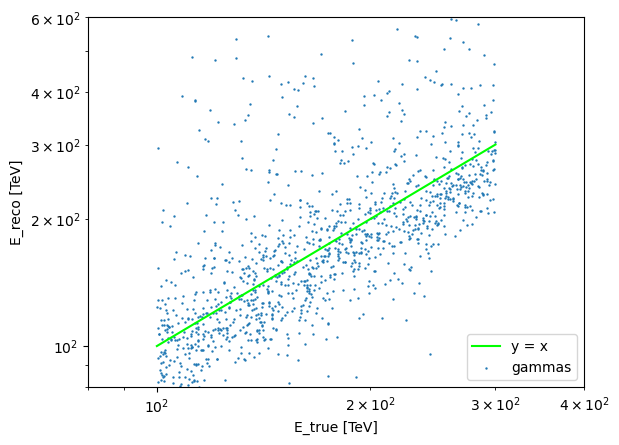

In [11]:
x_pts = np.logspace(2, np.log10(0.3e3), 100)
y_pts = x_pts
plt.plot(x_pts, y_pts, color = "lime", label = "y = x")
plt.scatter(E_True_list, E_reco_gammas, marker = ".", s = 2, label = "gammas")
plt.plot
plt.xlabel("E_true [TeV]")
plt.ylabel("E_reco [TeV]")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.xlim(0.8e2, 0.4e3)
plt.ylim(0.8e2, 0.6e3)
plt.savefig("pictures/other/ErecovsEtrue_gamma.png", dpi = 300)

plt.show()

In [12]:
"""x_pts = np.logspace(2, 3, 100)
y_pts = x_pts
plt.plot(x_pts, y_pts, color = "lime", label = "y = x")
plt.scatter(E_True_list_proton, E_reco_protons, marker = ".", s = 2, label = "protons", color = "red")
plt.plot
plt.xlabel("E_true [TeV]")
plt.ylabel("E_reco [TeV]")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.xlim(1e2, 3.1e2)
plt.show()"""

'x_pts = np.logspace(2, 3, 100)\ny_pts = x_pts\nplt.plot(x_pts, y_pts, color = "lime", label = "y = x")\nplt.scatter(E_True_list_proton, E_reco_protons, marker = ".", s = 2, label = "protons", color = "red")\nplt.plot\nplt.xlabel("E_true [TeV]")\nplt.ylabel("E_reco [TeV]")\nplt.xscale("log")\nplt.yscale("log")\nplt.legend()\nplt.xlim(1e2, 3.1e2)\nplt.show()'